# Road proximity and building-use experiment

This separate experiment tests whether OSM building, land-use, road and parking features help classify residential use.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


## 1. Install dependencies (run once)

Uncomment to install. Requires `osmnx>=1.6` (works with the latest 2.x as well).

In [ ]:
# !pip install osmnx geopandas pandas shapely scikit-learn jenkspy matplotlib graphviz

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely
from shapely.geometry import Polygon, MultiPolygon

import matplotlib.pyplot as plt
from sklearn import tree, metrics, preprocessing
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import jenkspy

# OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = False

# Projected CRS for the UK (British National Grid, metres)
UK_CRS = 27700
WGS84 = 4326

## 2. Define study area and download OSM data

We use the place name `"Guildford, Surrey, England, UK"`. OSMnx geocodes it via Nominatim and pulls the administrative polygon. All subsequent queries are clipped to this polygon.

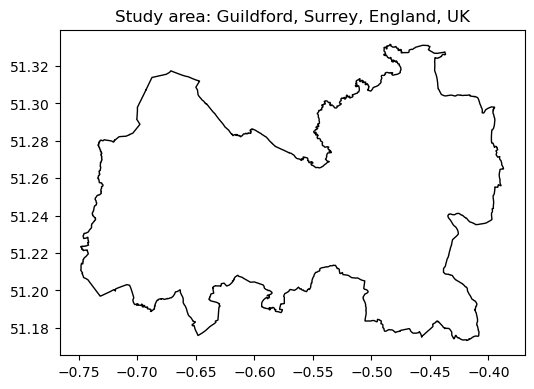

Bounds: [-0.7483397 51.1731853 -0.3871653 51.3315157]


In [2]:
place_name = "Guildford, Surrey, England, UK"

# Get the polygon boundary of Guildford
study_area = ox.geocode_to_gdf(place_name)
study_area = study_area.to_crs(epsg=WGS84)
study_area.plot(figsize=(6,6), edgecolor='black', facecolor='none')
plt.title(f"Study area: {place_name}")
plt.show()
study_polygon = study_area.geometry.iloc[0]
print("Bounds:", study_area.total_bounds)

In [4]:
# --- Download buildings ---
# `features_from_polygon` is the modern OSMnx API (replaces geometries_from_polygon)
tags = {"building": True}
buildings_raw = ox.features_from_polygon(study_polygon, tags=tags)
print("Raw buildings rows:", buildings_raw.shape)
buildings_raw.head(3)

Saved run recorded ReadTimeout. Detailed traceback omitted from the review copy.


In [4]:
# Keep only polygon/multipolygon geometries (drop building nodes)
buildings = buildings_raw[buildings_raw.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
buildings = buildings.reset_index()  # so 'osmid' becomes a column instead of an index level

# Standardise an 'id' column similar to the Boulder notebook
if 'osmid' in buildings.columns:
    buildings['id'] = buildings['osmid']
else:
    buildings['id'] = buildings.index

# Stash all raw tags as a dict per row, mimicking osmium's `all_tags` / `all_tag_keys`
_tag_cols = [c for c in buildings.columns if c not in ('id','osmid','element_type','geometry','element','nodes')]
buildings['all_tags'] = buildings[_tag_cols].apply(
    lambda r: {k: v for k, v in r.dropna().to_dict().items()}, axis=1)
buildings['all_tag_keys'] = buildings['all_tags'].apply(lambda d: list(d.keys()))

# Keep the 'building' tag value column explicit
if 'building' not in buildings.columns:
    buildings['building'] = 'yes'
buildings['building'] = buildings['building'].fillna('yes')

gdf = buildings[['id','building','geometry','all_tag_keys','all_tags']].copy()
gdf = gpd.GeoDataFrame(gdf, geometry='geometry', crs=WGS84)
print("Buildings (polygons only):", gdf.shape)
gdf.head()

Buildings (polygons only): (45670, 5)


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


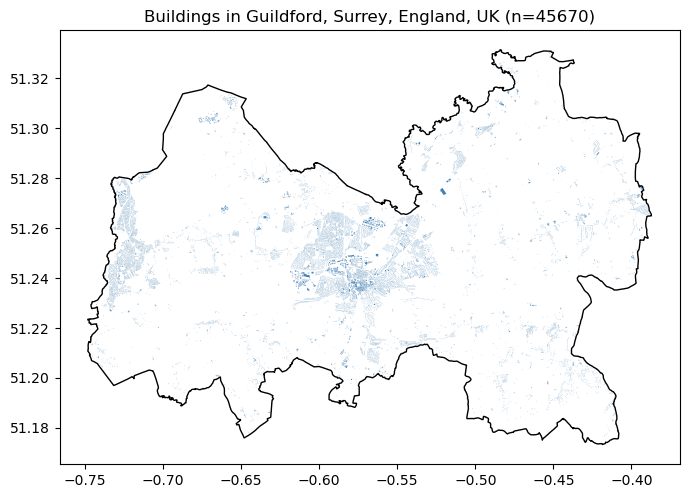

In [5]:
fig, ax = plt.subplots(figsize=(8,8))
study_area.plot(ax=ax, edgecolor='black', facecolor='none')
gdf.plot(ax=ax, color='steelblue', linewidth=0.2)
ax.set_title(f"Buildings in {place_name} (n={len(gdf)})")
plt.show()

In [6]:
# --- Download landuse polygons ---
land_raw = ox.features_from_polygon(study_polygon, tags={"landuse": True})
land_raw = land_raw[land_raw.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
land_raw = land_raw.reset_index()
land_df = land_raw[['landuse', 'geometry']].copy()
land_df = land_df.dropna(subset=['landuse'])
print("Landuse polygons:", land_df.shape)
land_df.groupby('landuse').size().sort_values(ascending=False).head(20)

Landuse polygons: (4520, 2)


landuse
grass                952
meadow               902
farmland             898
residential          661
farmyard             366
industrial            93
recreation_ground     87
retail                76
commercial            74
village_green         57
garages               55
railway               48
forest                45
allotments            30
construction          28
military              24
plant_nursery         21
cemetery              20
flowerbed             17
vineyard              14
dtype: int64

In [7]:
# Same recoding as Boulder: collapse a fixed list of categories under 'non_res'
non_res = ['commercial', 'retail', 'industrial', 'grass','meadow','farmland','farmyard','plant_nursery',
          'quarry', 'railway', 'government', 'institutional']
land_df['landuse'] = land_df['landuse'].apply(lambda x: 'non_res' if x in non_res else x)
land_gdf = gpd.GeoDataFrame(land_df, geometry='geometry', crs=WGS84)
land_gdf.groupby('landuse').size().sort_values(ascending=False)

landuse
non_res                    3439
residential                 661
recreation_ground            87
village_green                57
garages                      55
forest                       45
allotments                   30
construction                 28
military                     24
cemetery                     20
flowerbed                    17
vineyard                     14
religious                    11
brownfield                   10
orchard                       9
traffic_island                5
basin                         3
conservation                  1
greenhouse_horticulture       1
landfill                      1
education                     1
reservoir                     1
dtype: int64

In [8]:
# --- Download roads ---
# Use features_from_polygon to get road LINESTRINGS with their `highway` tag.
# (graph_from_polygon would also work but features_* maps more directly to the Boulder pipeline.)
roads_raw = ox.features_from_polygon(study_polygon, tags={"highway": True})
roads_raw = roads_raw[roads_raw.geometry.type.isin(["LineString", "MultiLineString"])].copy()
roads_raw = roads_raw.reset_index()
if 'osmid' in roads_raw.columns:
    roads_raw['id'] = roads_raw['osmid']
else:
    roads_raw['id'] = roads_raw.index
roads_df = roads_raw[['id', 'highway', 'geometry']].copy()
# Some rows have list-valued highway (rare); flatten to first value
roads_df['highway'] = roads_df['highway'].apply(lambda v: v[0] if isinstance(v, list) else v)
print("Road segments:", roads_df.shape)
roads_df.groupby('highway').size().sort_values(ascending=False).head(20)

Road segments: (25778, 3)


highway
service          8710
footway          4884
path             3463
residential      2909
track            1559
primary           866
bridleway         609
unclassified      608
cycleway          500
tertiary          495
steps             364
secondary         266
trunk             151
trunk_link        120
living_street      63
construction       62
corridor           51
primary_link       43
pedestrian         20
motorway           16
dtype: int64

In [9]:
# --- Download amenities (we only need parking from this) ---
amenity_raw = ox.features_from_polygon(study_polygon, tags={"amenity": True})
amenity_raw = amenity_raw[amenity_raw.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
amenity_raw = amenity_raw.reset_index()
amenity_df = amenity_raw[['amenity', 'geometry']].rename(columns={'amenity':'amenity_key'}).copy()
amenity_df = amenity_df.dropna(subset=['amenity_key'])
print("Amenity polygons:", amenity_df.shape)
amenity_df.groupby('amenity_key').size().sort_values(ascending=False).head(15)

Amenity polygons: (1688, 2)


amenity_key
parking             1021
parking_space        100
place_of_worship      81
school                73
pub                   47
community_centre      44
shelter               40
grave_yard            27
cafe                  20
restaurant            19
social_facility       17
fuel                  13
bar                   13
toilets               12
doctors               12
dtype: int64

## 3. Building-use labels

This experiment uses informative OSM building tags as training labels. Those labels are not independent survey ground truth, so the results are exploratory.


In [10]:
RES_TAGS = {
    'residential', 'apartments', 'house', 'detached', 'semidetached_house',
    'terrace', 'bungalow', 'dormitory', 'cabin', 'farm'
}
NON_RES_TAGS = {
    'commercial', 'retail', 'industrial', 'office', 'warehouse',
    'school', 'university', 'kindergarten', 'college',
    'church', 'cathedral', 'chapel', 'mosque', 'synagogue', 'temple', 'religious',
    'hospital', 'clinic',
    'public', 'civic', 'government', 'fire_station', 'train_station',
    'hotel', 'supermarket', 'sports_hall', 'stadium', 'pavilion'
}
DROP_TAGS = {'garage','garages','shed','roof','carport','greenhouse','hut','ruins','construction',
             'static_caravan','barn','stable'}  # mirrors Boulder's drop list

def derive_label(b):
    if b in RES_TAGS:
        return 'RES'
    if b in NON_RES_TAGS:
        return 'NON_RES'
    return None  # 'yes' / unknown / drop_tags -> unlabelled

official_buildings = gdf.copy()
official_buildings['official_type'] = official_buildings['building'].apply(derive_label)
# Drop rows in DROP_TAGS and unlabelled rows for the labelled set
official_buildings = official_buildings[~official_buildings['building'].isin(DROP_TAGS)].copy()
official_buildings = official_buildings[official_buildings['official_type'].notna()].copy()
official_buildings = official_buildings[['id','geometry','official_type']].reset_index(drop=True)
print('Labelled building counts:')
print(official_buildings.groupby('official_type').size())
print('Total labelled:', len(official_buildings))

Labelled building counts:
official_type
NON_RES      566
RES        13992
dtype: int64
Total labelled: 14558


## 4. Spatial join: buildings × landuse → `land_building`

In [11]:
buildings_land = gdf.sjoin(land_gdf, how="left", predicate='intersects')
buildings_land.drop_duplicates(subset='id', inplace=True)
buildings_land.rename(columns={'index_right': 'index_landuse'}, inplace=True)
buildings_land['landuse'] = buildings_land['landuse'].apply(
    lambda x: 'no_landuse' if pd.isnull(x) else x)
buildings_land.reset_index(inplace=True, drop=True)
print(buildings_land.shape)
buildings_land.groupby('landuse').size().sort_values(ascending=False).head(15)

(45670, 7)


landuse
residential                39583
non_res                     3220
no_landuse                  2463
military                     140
garages                       87
recreation_ground             79
cemetery                      23
construction                  21
forest                        19
religious                     12
village_green                  7
orchard                        5
allotments                     3
education                      3
greenhouse_horticulture        2
dtype: int64

In [12]:
buildings_land

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


In [13]:
# Combine landuse and building tag into 'land_building' (Boulder's enrichment logic)
buildings_land['land_building'] = buildings_land.apply(
    lambda x: x['landuse'] if x['building'] == 'yes' else x['building'], axis=1)

def enrich_buildings(df, tags_list):
    for tag_val in tags_list:
        df['land_building'] = df.apply(
            lambda x: tag_val if x['landuse'] == tag_val else x['land_building'], axis=1)
    return df

tags_list = ['residential','commercial','religious','recreation_ground','cemetery',
            'construction','farmland','farmyard','forest','military']
buildings_land = enrich_buildings(buildings_land, tags_list)
buildings_land.groupby('land_building').size().sort_values(ascending=False).head(15)

land_building
residential          39609
non_res               2619
no_landuse            1858
static_caravan         168
house                  153
military               140
farm_auxiliary         123
detached                98
recreation_ground       79
retail                  68
garages                 68
school                  67
industrial              60
commercial              57
roof                    36
dtype: int64

In [14]:
# Spatial join with our 'official' (here: OSM-derived) labelled set, on intersects
# (Both layers are in the same CRS, building polygons mostly identical, so this is a near 1:1 join.)
buildings_gdf = buildings_land.sjoin(
    official_buildings[['id','official_type','geometry']].rename(columns={'id':'id_official'}),
    how='inner', predicate='intersects')
buildings_gdf.rename(columns={'index_right':'index_official'}, inplace=True)
buildings_gdf.drop_duplicates(subset='id', inplace=True)
print('Buildings with label:', buildings_gdf.shape)
buildings_gdf.groupby(['land_building','official_type']).size().head(20)

Buildings with label: (15484, 11)


land_building  official_type
apartments     RES               12
bridge         NON_RES            1
cathedral      NON_RES            1
cemetery       NON_RES            5
chapel         NON_RES            2
church         NON_RES           15
civic          NON_RES            5
college        NON_RES            1
commercial     NON_RES           57
construction   NON_RES            1
detached       RES               98
dormitory      RES                1
farm           RES                4
garages        NON_RES            1
               RES                4
hospital       NON_RES            4
hotel          NON_RES            2
house          RES              153
industrial     NON_RES           60
military       NON_RES            2
dtype: int64

## 5. Road category buffers (4 categories × 3 radii)

Boulder grouped highways into 4 categories. We keep the same scheme — they map cleanly to UK road classifications (A roads ≈ primary/secondary/trunk, motorways = M roads):

| Cat | OSM `highway` values | Meaning |
|---|---|---|
| 1 | `residential`, `living_street` | Quiet residential streets |
| 2 | `primary`, `secondary`, `tertiary` | Through routes / A & B roads |
| 3 | `motorway`, `trunk` | High-speed major roads (M25, A3 trunk sections nearby) |
| 4 | `service` | Service roads / driveways (often link to non-residential sites) |

Buffers: 30 / 60 / 90 m, projected in EPSG:27700.

In [15]:
roads_cat1 = roads_df[roads_df['highway'].isin(['residential','living_street'])].copy()
roads_cat1 = roads_cat1.assign(highway='residential')
roads_cat1 = gpd.GeoDataFrame(roads_cat1, geometry='geometry', crs=WGS84)

roads_cat2 = roads_df[roads_df['highway'].isin(['primary','secondary','tertiary'])].copy()
roads_cat2 = roads_cat2.assign(highway='non_res_road')
roads_cat2 = gpd.GeoDataFrame(roads_cat2, geometry='geometry', crs=WGS84)

roads_cat3 = roads_df[roads_df['highway'].isin(['motorway','trunk'])].copy()
roads_cat3 = roads_cat3.assign(highway='roads_cat3')
roads_cat3 = gpd.GeoDataFrame(roads_cat3, geometry='geometry', crs=WGS84)

roads_cat4 = roads_df[roads_df['highway'] == 'service'].copy()
roads_cat4 = gpd.GeoDataFrame(roads_cat4, geometry='geometry', crs=WGS84)

for name, rc in [('cat1',roads_cat1),('cat2',roads_cat2),('cat3',roads_cat3),('cat4',roads_cat4)]:
    print(f'{name}: {rc.shape[0]} segments')

cat1: 2972 segments
cat2: 1627 segments
cat3: 167 segments
cat4: 8710 segments


In [16]:
def apply_buffers(radius, road_category):
    """Buffer a road LineString GeoDataFrame by `radius` metres in EPSG:27700, then dissolve."""
    rc = road_category.copy()
    rc['geometry'] = rc['geometry'].to_crs(epsg=UK_CRS).buffer(radius)
    rc = rc.set_crs(UK_CRS, allow_override=True).to_crs(epsg=WGS84)
    rc.rename(columns={'highway':'buffered_highway'}, inplace=True)
    rc = rc.dissolve()
    return rc

radius_list = [30, 60, 90]   # metres
buffered_cat1_30 = apply_buffers(radius_list[0], roads_cat1)
buffered_cat1_60 = apply_buffers(radius_list[1], roads_cat1)
buffered_cat1_90 = apply_buffers(radius_list[2], roads_cat1)
buffered_cat2_30 = apply_buffers(radius_list[0], roads_cat2)
buffered_cat2_60 = apply_buffers(radius_list[1], roads_cat2)
buffered_cat2_90 = apply_buffers(radius_list[2], roads_cat2)
buffered_cat3_30 = apply_buffers(radius_list[0], roads_cat3)
buffered_cat3_60 = apply_buffers(radius_list[1], roads_cat3)
buffered_cat3_90 = apply_buffers(radius_list[2], roads_cat3)
buffered_cat4_30 = apply_buffers(radius_list[0], roads_cat4)
buffered_cat4_60 = apply_buffers(radius_list[1], roads_cat4)
buffered_cat4_90 = apply_buffers(radius_list[2], roads_cat4)
print('Buffers built.')

Buffers built.


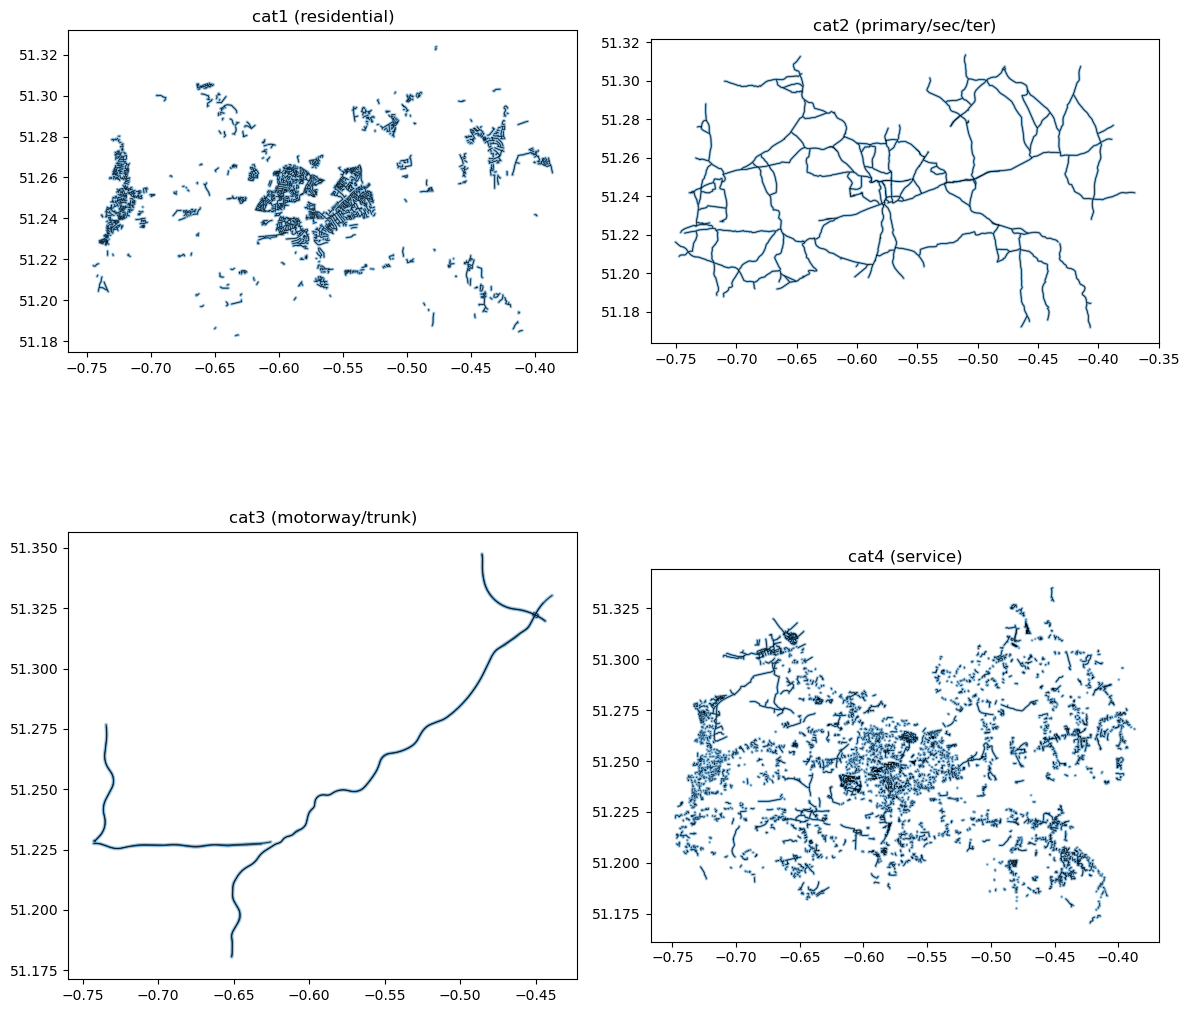

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12,12))
for ax, (label, b30, b60, b90, raw) in zip(axes.flatten(), [
    ('cat1 (residential)', buffered_cat1_30, buffered_cat1_60, buffered_cat1_90, roads_cat1),
    ('cat2 (primary/sec/ter)', buffered_cat2_30, buffered_cat2_60, buffered_cat2_90, roads_cat2),
    ('cat3 (motorway/trunk)', buffered_cat3_30, buffered_cat3_60, buffered_cat3_90, roads_cat3),
    ('cat4 (service)', buffered_cat4_30, buffered_cat4_60, buffered_cat4_90, roads_cat4),
]):
    if not b90.empty: b90.plot(ax=ax, alpha=0.25, color='C0')
    if not b60.empty: b60.plot(ax=ax, alpha=0.35, color='C0')
    if not b30.empty: b30.plot(ax=ax, alpha=0.55, color='C0')
    if not raw.empty: raw.plot(ax=ax, color='black', linewidth=0.4)
    ax.set_title(label)
plt.tight_layout(); plt.show()

In [20]:
def join_buildings(buffer_category, roads_category):
    buffered_category = {
        'cat1_30': buffered_cat1_30, 'cat1_60': buffered_cat1_60, 'cat1_90': buffered_cat1_90,
        'cat2_30': buffered_cat2_30, 'cat2_60': buffered_cat2_60, 'cat2_90': buffered_cat2_90,
        'cat3_30': buffered_cat3_30, 'cat3_60': buffered_cat3_60, 'cat3_90': buffered_cat3_90,
        'cat4_30': buffered_cat4_30, 'cat4_60': buffered_cat4_60, 'cat4_90': buffered_cat4_90,
    }.get(buffer_category)

    # Pick whichever id column survived the earlier sjoins
    id_col = next((c for c in ('id', 'id_left', 'id_right') if c in buildings_gdf.columns), None)
    if id_col is None:
        raise KeyError(f"No id column found. Available: {list(buildings_gdf.columns)}")

    if buffered_category is None or buffered_category.empty:
        joined = buildings_gdf.copy()
        joined['buffered_highway'] = 'not_residential' if roads_category else 'residential'
        return joined

    joined = buildings_gdf.sjoin(buffered_category, how='left')
    joined.rename(columns={'index_right': 'index_roads'}, inplace=True)
    if roads_category:
        joined['buffered_highway'] = joined['buffered_highway'].apply(
            lambda x: 'not_residential' if pd.isnull(x) else x)
    else:
        joined['buffered_highway'] = joined['buffered_highway'].apply(
            lambda x: 'residential' if pd.isnull(x) else x)

    # After this second sjoin, the id column may have been suffixed again
    id_col_after = next((c for c in (id_col, 'id', 'id_left') if c in joined.columns), None)
    joined = joined.drop_duplicates(subset=id_col_after)
    joined.reset_index(inplace=True, drop=True)
    return joined

In [21]:
buffer_categories = ['cat1_30','cat1_60','cat1_90','cat2_30','cat2_60','cat2_90',
                    'cat3_30','cat3_60','cat3_90','cat4_30','cat4_60','cat4_90']
# 1 = residential cat (treat residential as label); 0 = non-res cats
joined_buildings1  = join_buildings(buffer_categories[0], 1)
joined_buildings2  = join_buildings(buffer_categories[1], 1)
joined_buildings3  = join_buildings(buffer_categories[2], 1)
joined_buildings4  = join_buildings(buffer_categories[3], 0)
joined_buildings5  = join_buildings(buffer_categories[4], 0)
joined_buildings6  = join_buildings(buffer_categories[5], 0)
joined_buildings7  = join_buildings(buffer_categories[6], 0)
joined_buildings8  = join_buildings(buffer_categories[7], 0)
joined_buildings9  = join_buildings(buffer_categories[8], 0)
joined_buildings10 = join_buildings(buffer_categories[9], 0)
joined_buildings11 = join_buildings(buffer_categories[10], 0)
joined_buildings12 = join_buildings(buffer_categories[11], 0)
for i, jb in enumerate([joined_buildings1, joined_buildings2, joined_buildings3,
                       joined_buildings4, joined_buildings5, joined_buildings6,
                       joined_buildings7, joined_buildings8, joined_buildings9,
                       joined_buildings10, joined_buildings11, joined_buildings12], 1):
    print(f'joined_buildings{i}: {jb.shape}')

joined_buildings1: (15484, 14)
joined_buildings2: (15484, 14)
joined_buildings3: (15484, 14)
joined_buildings4: (15484, 14)
joined_buildings5: (15484, 14)
joined_buildings6: (15484, 14)
joined_buildings7: (15484, 14)
joined_buildings8: (15484, 14)
joined_buildings9: (15484, 14)
joined_buildings10: (15484, 14)
joined_buildings11: (15484, 14)
joined_buildings12: (15484, 14)


## 6. Tag-presence features and pre-processing

In [22]:
# Build tag-key frequency table (which OSM keys appear most often on Guildford buildings)
keys_list_flat = [k for keys in gdf['all_tag_keys'] for k in keys]
keys_freq = pd.Series(keys_list_flat).value_counts().reset_index()
keys_freq.columns = ['Key','Freq']
keys_freq.head(25)

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


In [23]:
# Same selected_tags as Boulder. UK OSM has good coverage of addr:street, name, building:levels.
selected_tags = ['source','addr:street','name','building:levels',
                'roof:shape','amenity','brand','website','shop']
value_tags    = ['roof:shape','building:levels']  # tags whose VALUE we keep, not just presence

In [24]:
def preprocess_data(input_data, value_tags, selected_tags):
    # Insert a 0/1 presence column for every selected_tag
    col_pos = 2
    for tag_key in selected_tags:
        input_data.insert(col_pos, tag_key, 0)
        input_data[tag_key] = input_data.apply(
            lambda x: 1 if tag_key in list(x['all_tag_keys']) else 0, axis=1)
    # For value_tags, keep the actual value (or 0)
    for tag_key in value_tags:
        input_data[tag_key] = input_data.apply(
            lambda x: x['all_tags'].get(tag_key) if tag_key in list(x['all_tag_keys']) else 0, axis=1)
    # Clean common malformed building:levels values
    input_data.drop(input_data[input_data['building:levels'] == 'K-6'].index, inplace=True, errors='ignore')
    input_data.loc[input_data['building:levels'] == '-1,1,2,3', 'building:levels'] = 4
    input_data.loc[input_data['building:levels'] == '1;3;2',   'building:levels'] = 3
    input_data.loc[input_data['building:levels'] == '4 floors','building:levels'] = 4
    # Drop helper columns
    input_data.drop(columns=['all_tag_keys','all_tags'], inplace=True, errors='ignore')
    # Encode label: 1 = RES, 0 = NON_RES
    input_data['official_type'] = input_data['official_type'].apply(lambda x: 1 if x == 'RES' else 0)
    return input_data

def add_buffers(input_data, col_names, buffers_list):
    for num in range(len(col_names)):
        input_data.insert(num+2, col_names[num], list(buffers_list[num]))
        input_data[col_names[num]] = input_data[col_names[num]].apply(
            lambda x: 1 if x == 'residential' else 0)
    return input_data

In [27]:
col_names = ['buffer_cat1_30','buffer_cat1_60','buffer_cat1_90',
            'buffer_cat2_30','buffer_cat2_60','buffer_cat2_90',
            'buffer_cat3_30','buffer_cat3_60','buffer_cat3_90',
            'buffer_cat4_30','buffer_cat4_60','buffer_cat4_90']
buffers_list = [joined_buildings1['buffered_highway'].values, joined_buildings2['buffered_highway'].values,
                joined_buildings3['buffered_highway'].values, joined_buildings4['buffered_highway'].values,
                joined_buildings5['buffered_highway'].values, joined_buildings6['buffered_highway'].values,
                joined_buildings7['buffered_highway'].values, joined_buildings8['buffered_highway'].values,
                joined_buildings9['buffered_highway'].values, joined_buildings10['buffered_highway'].values,
                joined_buildings11['buffered_highway'].values, joined_buildings12['buffered_highway'].values]

backup_data = joined_buildings1.copy()
backup_data = backup_data[['geometry','official_type','building','landuse','land_building',
                          'all_tag_keys','all_tags','id_left']]
# id_left is already the canonical building id at this point — leave it.

backup_data.insert(len(backup_data.columns), 'area', backup_data['geometry'].to_crs(epsg=UK_CRS).area)
backup_data = preprocess_data(backup_data, value_tags, selected_tags)
backup_data = add_buffers(backup_data, col_names, buffers_list)
print(backup_data.shape)
backup_data.head()

(15484, 28)


,geometry,official_type,buffer_cat1_30,buffer_cat1_60,buffer_cat1_90,buffer_cat2_30,buffer_cat2_60,buffer_cat2_90,buffer_cat3_30,buffer_cat3_60,...,roof:shape,building:levels,name,addr:street,source,building,landuse,land_building,id_left,area
0,"POLYGON ((-0.58798 51.24379, -0.58798 51.24368...",0,0,0,0,1,1,1,1,1,...,hipped,3,1,1,0,university,non_res,university,0,1819.116365
1,"POLYGON ((-0.60923 51.24066, -0.60929 51.24067...",0,0,0,0,1,0,0,1,1,...,0,0,1,0,0,hospital,non_res,hospital,2,19507.572071
2,"POLYGON ((-0.61344 51.23859, -0.61324 51.23841...",0,0,1,1,1,1,1,1,1,...,0,0,1,1,0,commercial,non_res,commercial,3,5594.054860
3,"POLYGON ((-0.61301 51.23783, -0.61298 51.23783...",1,1,1,1,1,1,1,1,1,...,0,0,1,0,1,dormitory,residential,residential,5,3623.495752
4,"POLYGON ((-0.57002 51.23774, -0.57005 51.23778...",0,0,1,1,1,0,0,1,1,...,0,4,1,1,1,school,non_res,school,8,3225.442591


## 7. Parking buffers (Jenks-classified)

In [28]:
parking_df = amenity_df[amenity_df['amenity_key'].isin(['parking','parking_space'])].copy()
parking_df['amenity_key'] = 'parking'
parking_df.reset_index(drop=True, inplace=True)
parking_gdf = gpd.GeoDataFrame(parking_df, geometry='geometry', crs=WGS84)
parking_gdf.insert(len(parking_gdf.columns), 'parking_area',
                  parking_gdf['geometry'].to_crs(epsg=UK_CRS).area)
print(parking_gdf.shape)
parking_gdf.head()

(1121, 3)


,amenity_key,geometry,parking_area
0,parking,"POLYGON ((-0.45327 51.31697, -0.45325 51.3168,...",3001.532769
1,parking,"POLYGON ((-0.62173 51.21223, -0.62147 51.21226...",1313.582877
2,parking,"POLYGON ((-0.60614 51.24479, -0.60622 51.2445,...",2025.537623
3,parking,"POLYGON ((-0.60599 51.24516, -0.60591 51.2456,...",1075.774127
4,parking,"POLYGON ((-0.55986 51.24934, -0.56005 51.24978...",5663.451712


In [29]:
if len(parking_gdf) >= 3:
    breaks = jenkspy.jenks_breaks(parking_gdf['parking_area'].values, n_classes=3)
    print('Jenks breaks (m²):', breaks)
    bins_list = ['bin1','bin2','bin3']
    parking_gdf['cut_jenks'] = pd.cut(parking_gdf['parking_area'], bins=breaks,
                                      labels=bins_list, include_lowest=True)
    for b in bins_list:
        parking_gdf.insert(len(parking_gdf.columns), b, 0)
        parking_gdf[b] = parking_gdf.apply(lambda x: 1 if x['cut_jenks'] == b else 0, axis=1)
    have_parking = True
else:
    print('Too few parking polygons for Jenks; skipping parking features.')
    bins_list = []
    have_parking = False

Jenks breaks (m²): [np.float64(9.476846336924039), np.float64(2290.5297467841774), np.float64(8909.131415716047), np.float64(24473.567774955274)]


In [30]:
if have_parking:
    radius_list = [30, 60, 90]
    counter = 1
    for b in bins_list:
        for radius in radius_list:
            pb = parking_gdf.copy()
            pb = pb[['geometry', b]]
            col_name = f'parking_cat{counter}'
            counter += 1
            pb.rename(columns={b: col_name}, inplace=True)
            pb['geometry'] = pb['geometry'].to_crs(epsg=UK_CRS).buffer(radius)
            pb = pb.set_crs(UK_CRS, allow_override=True).to_crs(epsg=WGS84)
            bp = backup_data.sjoin(pb, how='left', predicate='intersects')
            bp[col_name] = bp[col_name].fillna(0)
            bp.drop_duplicates(subset='id_left', inplace=True)
            bp.reset_index(inplace=True, drop=True)
            backup_data.insert(len(backup_data.columns), col_name, list(bp[col_name]))
    print('Parking features added:', counter-1)
else:
    print('Skipped parking features.')

Parking features added: 9


In [31]:
backup_data.drop(columns=['id_left'], inplace=True, errors='ignore')
input_data = backup_data.copy()
input_data.drop(columns=['land_building','roof:shape'], inplace=True, errors='ignore')
print(input_data.shape)
input_data.columns.tolist()

(15484, 34)


['geometry',
 'official_type',
 'buffer_cat1_30',
 'buffer_cat1_60',
 'buffer_cat1_90',
 'buffer_cat2_30',
 'buffer_cat2_60',
 'buffer_cat2_90',
 'buffer_cat3_30',
 'buffer_cat3_60',
 'buffer_cat3_90',
 'buffer_cat4_30',
 'buffer_cat4_60',
 'buffer_cat4_90',
 'shop',
 'website',
 'brand',
 'amenity',
 'building:levels',
 'name',
 'addr:street',
 'source',
 'building',
 'landuse',
 'area',
 'parking_cat1',
 'parking_cat2',
 'parking_cat3',
 'parking_cat4',
 'parking_cat5',
 'parking_cat6',
 'parking_cat7',
 'parking_cat8',
 'parking_cat9']

## 8. Consolidate rare `building` and `landuse` values into 'misc' buckets

In [32]:
common_features = np.array(['apartments','church','civic','commercial','construction',
       'detached','dormitory','garage','garages','greenhouse',
       'hospital','hotel','house','industrial','kindergarten',
       'office','parking','public','residential','retail','roof',
       'school','semidetached_house','service','shed',
       'static_caravan','terrace','warehouse','yes'], dtype=object)

unique_buildings = np.setxor1d(input_data['building'].unique(), common_features).tolist()
input_data['building'] = input_data['building'].apply(
    lambda x: 'misc_buildings' if x in unique_buildings else x)

common_landuse = np.array(['non_res','no_landuse','residential','construction',
       'forest','recreation_ground','cemetery','farmyard'], dtype=object)
unique_landuse = np.setxor1d(input_data['landuse'].unique(), common_landuse).tolist()
input_data['landuse'] = input_data['landuse'].apply(
    lambda x: 'misc_landuse' if x in unique_landuse else x)
input_data['landuse'] = input_data['landuse'].replace({
    'residential':'residential_landuse', 'non_res':'non_res_landuse',
    'forest':'forest_landuse', 'cemetery':'cemetery_landuse',
    'recreation_ground':'recreation_ground_landuse',
    'construction':'construction_landuse', 'farmyard':'farmyard_landuse'})

print('Buildings:'); print(input_data.groupby('building').size().sort_values(ascending=False))
print('\nLanduse:'); print(input_data.groupby('landuse').size().sort_values(ascending=False))

Buildings:
building
house                 8941
semidetached_house    2614
detached              1605
garage                 471
terrace                333
yes                    276
residential            250
misc_buildings         168
apartments             167
school                 107
retail                  96
industrial              73
commercial              70
roof                    54
dormitory               45
church                  42
garages                 37
office                  36
shed                    30
public                  24
warehouse               24
civic                    8
hospital                 6
hotel                    5
parking                  1
kindergarten             1
dtype: int64

Landuse:
landuse
residential_landuse          14642
no_landuse                     418
non_res_landuse                374
misc_landuse                    31
recreation_ground_landuse       13
cemetery_landuse                 5
construction_landuse             1
dt

## 9. One-hot encode and train Decision Tree

In [33]:
def nominal_transform(input_data, value_tags):
    # `sparse=False` was deprecated in sklearn 1.2; new arg is `sparse_output=False`
    try:
        ohe = preprocessing.OneHotEncoder(sparse_output=False)
    except TypeError:
        ohe = preprocessing.OneHotEncoder(sparse=False)
    for tag in value_tags:
        ohe_results = ohe.fit_transform(input_data[[tag]])
        input_data.reset_index(inplace=True, drop=True)
        input_data = pd.concat([input_data,
            pd.DataFrame(ohe_results, columns=ohe.categories_[0].tolist())], axis=1)
        input_data.drop(columns=[tag], inplace=True)
    return input_data

In [34]:
value_tags_for_ohe = ['building','landuse']
nominal_data = input_data.copy()
nominal_data = nominal_transform(nominal_data, value_tags_for_ohe)
# The first column is geometry, second is the label official_type. Features are everything after.
nominal_features = [c for c in nominal_data.columns if c not in ('geometry','official_type')]
# building:levels may still hold non-numeric values; coerce, fill 0
if 'building:levels' in nominal_data.columns:
    nominal_data['building:levels'] = pd.to_numeric(nominal_data['building:levels'], errors='coerce').fillna(0)
print('# features:', len(nominal_features))
print(nominal_features[:30])

# features: 63
['buffer_cat1_30', 'buffer_cat1_60', 'buffer_cat1_90', 'buffer_cat2_30', 'buffer_cat2_60', 'buffer_cat2_90', 'buffer_cat3_30', 'buffer_cat3_60', 'buffer_cat3_90', 'buffer_cat4_30', 'buffer_cat4_60', 'buffer_cat4_90', 'shop', 'website', 'brand', 'amenity', 'building:levels', 'name', 'addr:street', 'source', 'area', 'parking_cat1', 'parking_cat2', 'parking_cat3', 'parking_cat4', 'parking_cat5', 'parking_cat6', 'parking_cat7', 'parking_cat8', 'parking_cat9']


Confusion matrix:
[[ 115    4]
 [   9 2969]]


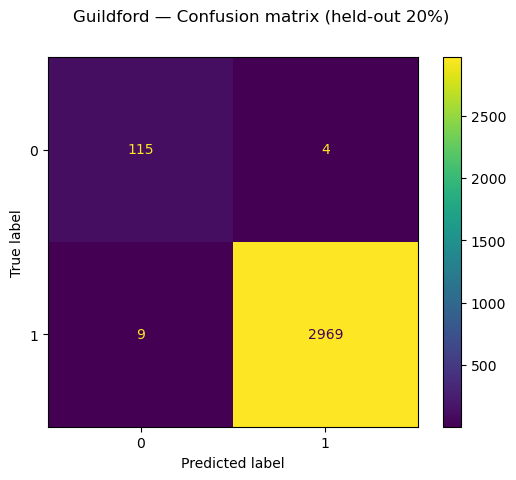

              precision    recall  f1-score   support

     NON_RES       0.93      0.97      0.95       119
         RES       1.00      1.00      1.00      2978

    accuracy                           1.00      3097
   macro avg       0.96      0.98      0.97      3097
weighted avg       1.00      1.00      1.00      3097



In [35]:
X = nominal_data[nominal_features]
y = nominal_data['official_type']
weights = {0: 2.0, 1: 1.0}  # same as Boulder: weight NON_RES higher

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=0)

dt_split = DecisionTreeClassifier(class_weight=weights, min_samples_split=20,
                                  random_state=0, min_impurity_decrease=0.0001)
dt_split.fit(X_train, y_train)
predicted = dt_split.predict(X_test)

disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted)
disp.figure_.suptitle('Guildford — Confusion matrix (held-out 20%)')
print('Confusion matrix:'); print(disp.confusion_matrix)
plt.show()
print(metrics.classification_report(y_test, predicted, target_names=['NON_RES','RES']))

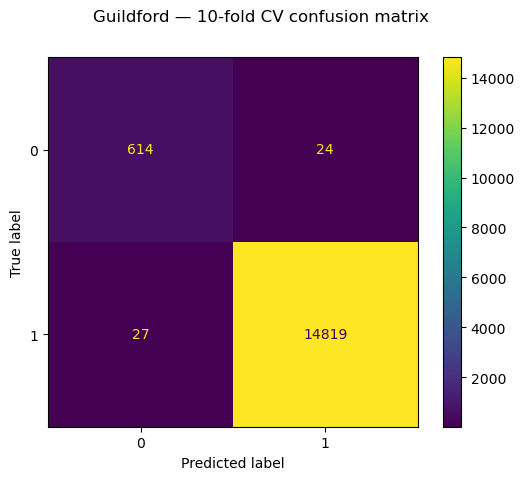

              precision    recall  f1-score   support

     NON_RES       0.96      0.96      0.96       638
         RES       1.00      1.00      1.00     14846

    accuracy                           1.00     15484
   macro avg       0.98      0.98      0.98     15484
weighted avg       1.00      1.00      1.00     15484



In [36]:
# 10-fold cross-validated predictions (used for the output shapefile in Boulder)
dt = DecisionTreeClassifier(class_weight=weights, min_samples_split=20,
                            random_state=0, min_impurity_decrease=0.0001)
y_pred_cv = cross_val_predict(dt, X, y, cv=10)
disp = metrics.ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
disp.figure_.suptitle('Guildford — 10-fold CV confusion matrix')
plt.show()
print(metrics.classification_report(y, y_pred_cv, target_names=['NON_RES','RES']))

## 10. Save predictions

In [37]:
import os
os.makedirs('./Guildford_Predictions', exist_ok=True)
os.makedirs('./Guildford_Processed_Data', exist_ok=True)

output_data = nominal_data.copy()
drop_cols = ['official_type'] + [c for c in ['buffer_cat2_30','buffer_cat2_60','buffer_cat2_90'] if c in output_data.columns]
output_data.drop(columns=drop_cols, inplace=True, errors='ignore')
output_data.insert(1, 'official', y.values)
output_data.insert(2, 'predicted', y_pred_cv)
output_data['official']  = output_data['official'].apply(lambda x: 'RES' if x == 1 else 'NON_RES')
output_data['predicted'] = output_data['predicted'].apply(lambda x: 'RES' if x == 1 else 'NON_RES')

# Shapefile column-name limit is 10 chars; geopandas will warn and truncate. GeoPackage avoids that.
output_gdf = gpd.GeoDataFrame(output_data, geometry='geometry', crs=WGS84)
output_gdf.to_file('./Guildford_Predictions/Guildford_Predictions.gpkg', driver='GPKG')
nominal_data.to_pickle('./Guildford_Processed_Data/Guildford_nominal_data.pkl')
print('Saved.')

Saved.


In [38]:
result = gpd.read_file('./Guildford_Predictions/Guildford_Predictions.gpkg')

In [39]:
result

,official,predicted,buffer_cat1_30,buffer_cat1_60,buffer_cat1_90,buffer_cat3_30,buffer_cat3_60,buffer_cat3_90,buffer_cat4_30,buffer_cat4_60,...,warehouse,yes,cemetery_landuse,construction_landuse,misc_landuse,no_landuse,non_res_landuse,recreation_ground_landuse,residential_landuse,geometry
0,NON_RES,NON_RES,0,0,0,1,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"MULTIPOLYGON (((-0.58798 51.24379, -0.58798 51..."
1,NON_RES,NON_RES,0,0,0,1,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"MULTIPOLYGON (((-0.60923 51.24066, -0.60929 51..."
2,NON_RES,NON_RES,0,1,1,1,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"MULTIPOLYGON (((-0.61344 51.23859, -0.61324 51..."
3,RES,RES,1,1,1,1,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"MULTIPOLYGON (((-0.61301 51.23783, -0.61298 51..."
4,NON_RES,NON_RES,0,1,1,1,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,"MULTIPOLYGON (((-0.57002 51.23774, -0.57005 51..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15479,RES,RES,1,1,1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"MULTIPOLYGON (((-0.43348 51.26946, -0.43345 51..."
15480,RES,RES,1,1,1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"MULTIPOLYGON (((-0.4344 51.26953, -0.43443 51...."
15481,RES,RES,1,1,1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"MULTIPOLYGON (((-0.43486 51.26948, -0.43487 51..."
15482,RES,RES,1,1,1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"MULTIPOLYGON (((-0.43525 51.26943, -0.43525 51..."


In [41]:


# ---- 1. Train final model on ALL labelled data ----
weights = {0: 2.0, 1: 1.0}
final_model = DecisionTreeClassifier(class_weight=weights, min_samples_split=20,
                                     random_state=0, min_impurity_decrease=0.0001)
final_model.fit(X, y)
print(f"Trained on {len(X)} labelled buildings, {len(nominal_features)} features")

# ---- 2. Build the same features for ALL buildings (no label filter) ----
# Start from the full buildings layer (gdf) and rebuild the feature pipeline
all_buildings = gdf.copy()

# Landuse join
all_b = all_buildings.sjoin(land_gdf, how='left', predicate='intersects')
all_b = all_b.drop_duplicates(subset='id').reset_index(drop=True)
all_b.rename(columns={'index_right': 'index_landuse'}, inplace=True)
all_b['landuse'] = all_b['landuse'].fillna('no_landuse')
all_b['land_building'] = all_b.apply(
    lambda x: x['landuse'] if x['building'] == 'yes' else x['building'], axis=1)

# Road buffers — sjoin each of the 12 buffer layers
buffer_layers = {
    'buffer_cat1_30': (buffered_cat1_30, 1), 'buffer_cat1_60': (buffered_cat1_60, 1),
    'buffer_cat1_90': (buffered_cat1_90, 1), 'buffer_cat2_30': (buffered_cat2_30, 0),
    'buffer_cat2_60': (buffered_cat2_60, 0), 'buffer_cat2_90': (buffered_cat2_90, 0),
    'buffer_cat3_30': (buffered_cat3_30, 0), 'buffer_cat3_60': (buffered_cat3_60, 0),
    'buffer_cat3_90': (buffered_cat3_90, 0), 'buffer_cat4_30': (buffered_cat4_30, 0),
    'buffer_cat4_60': (buffered_cat4_60, 0), 'buffer_cat4_90': (buffered_cat4_90, 0),
}
for col, (buf, is_res_cat) in buffer_layers.items():
    if buf is None or buf.empty:
        all_b[col] = 0
        continue
    j = all_b[['id','geometry']].sjoin(buf[['geometry','buffered_highway']],
                                       how='left', predicate='intersects')
    j = j.drop_duplicates(subset='id')
    label = 'residential' if is_res_cat else 'not_residential'  # we want 1 = residential
    all_b[col] = (j['buffered_highway'] == 'residential').astype(int).values

# Parking buffers
if have_parking:
    counter = 1
    for b in bins_list:
        for radius in [30, 60, 90]:
            pb = parking_gdf[['geometry', b]].copy()
            col_name = f'parking_cat{counter}'
            counter += 1
            pb.rename(columns={b: col_name}, inplace=True)
            pb['geometry'] = pb['geometry'].to_crs(epsg=UK_CRS).buffer(radius)
            pb = pb.set_crs(UK_CRS, allow_override=True).to_crs(epsg=WGS84)
            j = all_b[['id','geometry']].sjoin(pb, how='left', predicate='intersects')
            j[col_name] = j[col_name].fillna(0)
            j = j.drop_duplicates(subset='id')
            all_b[col_name] = j[col_name].values

# Tag-presence + value features
for tag_key in selected_tags:
    all_b[tag_key] = all_b['all_tag_keys'].apply(lambda keys: 1 if tag_key in keys else 0)
for tag_key in ['building:levels']:  # roof:shape was dropped earlier
    all_b[tag_key] = all_b.apply(
        lambda x: x['all_tags'].get(tag_key, 0) if tag_key in x['all_tag_keys'] else 0, axis=1)
all_b.loc[all_b['building:levels'] == '1;3;2', 'building:levels'] = 3
all_b.loc[all_b['building:levels'] == '4 floors', 'building:levels'] = 4
all_b['building:levels'] = pd.to_numeric(all_b['building:levels'], errors='coerce').fillna(0)

# Area
all_b['area'] = all_b['geometry'].to_crs(epsg=UK_CRS).area

# Consolidate rare categories — same lists as in training
common_features = np.array(['apartments','church','civic','commercial','construction',
       'detached','dormitory','garage','garages','greenhouse','hospital','hotel','house',
       'industrial','kindergarten','office','parking','public','residential','retail','roof',
       'school','semidetached_house','service','shed','static_caravan','terrace','warehouse','yes'])
all_b['building'] = all_b['building'].apply(
    lambda x: 'misc_buildings' if x not in common_features else x)
common_landuse = np.array(['non_res','no_landuse','residential','construction',
       'forest','recreation_ground','cemetery','farmyard'])
all_b['landuse'] = all_b['landuse'].apply(
    lambda x: 'misc_landuse' if x not in common_landuse else x)
all_b['landuse'] = all_b['landuse'].replace({
    'residential':'residential_landuse', 'non_res':'non_res_landuse',
    'forest':'forest_landuse', 'cemetery':'cemetery_landuse',
    'recreation_ground':'recreation_ground_landuse',
    'construction':'construction_landuse', 'farmyard':'farmyard_landuse'})

# One-hot encode building & landuse, then align columns to training set
all_b_ohe = pd.get_dummies(all_b, columns=['building','landuse'], prefix='', prefix_sep='')
# Add any missing training columns as 0, drop any extras, reorder to match
for col in nominal_features:
    if col not in all_b_ohe.columns:
        all_b_ohe[col] = 0
X_all = all_b_ohe[nominal_features].astype(float)

# ---- 3. Predict on EVERY building ----
all_b['predicted'] = final_model.predict(X_all)
all_b['predicted'] = all_b['predicted'].apply(lambda v: 'RES' if v == 1 else 'NON_RES')

print(f"\nClassified {len(all_b)} buildings:")
print(all_b['predicted'].value_counts())

Trained on 15484 labelled buildings, 63 features

Classified 45670 buildings:
predicted
RES        39912
NON_RES     5758
Name: count, dtype: int64


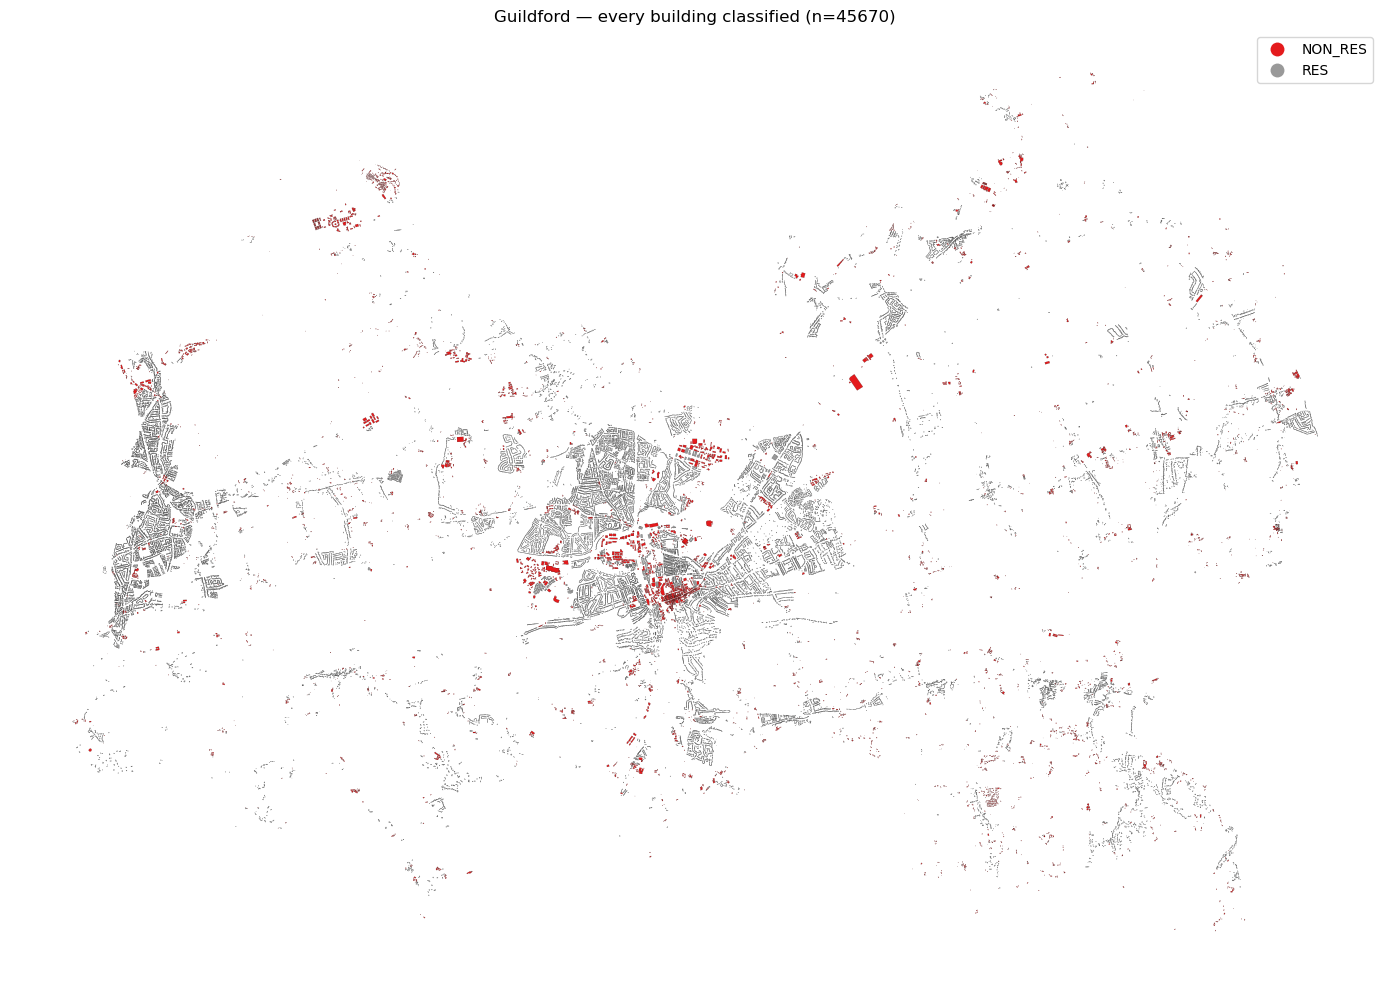


Saved to ./Guildford_Predictions/Guildford_All_Buildings_Classified.gpkg


In [42]:
fig, ax = plt.subplots(figsize=(14, 14))
all_b.plot(column='predicted', ax=ax, legend=True,
           categorical=True, cmap='Set1', linewidth=0.1, edgecolor='black')
ax.set_title(f'Guildford — every building classified (n={len(all_b)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Or interactive
all_b[['geometry','building','predicted']].explore(
    column='predicted', categorical=True, cmap='Set1',
    tiles='CartoDB positron')

# Save
all_b_out = gpd.GeoDataFrame(all_b[['id','geometry','building','predicted']],
                             geometry='geometry', crs=4326)
all_b_out.to_file('./Guildford_Predictions/Guildford_All_Buildings_Classified.gpkg', driver='GPKG')
print("\nSaved to ./Guildford_Predictions/Guildford_All_Buildings_Classified.gpkg")